<a href="https://colab.research.google.com/github/smok313-zdr/InsigniaNet/blob/main/InsigniaNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import training data from GitHub

This code snippet copies the structure of the 'military_ribbon_dataset' directory from GitHub, where images for training the model will be stored. The location where the new directory structure will be created is defined in the `root_directory` variable.

In [14]:
import os
import subprocess
import shutil

def create_and_populate_directory(root_dir, github_url, target_folder):
    """Creates directory structure for 'ribbons' dataset and
    populates it with data from GitHub using git clone.

    Args:
        root_dir: The root directory where the structure will be created.
        github_url: The URL of the GitHub repository containing the data.
        target_folder: The specific folder to clone from the repository.
    """

    # Temporary directory for cloning the repository
    temp_dir = os.path.join(root_dir, "temp_repo")
    # Ensure the temporary directory is empty before cloning
    if os.path.exists(temp_dir):
        shutil.rmtree(temp_dir)
    os.makedirs(temp_dir, exist_ok=True)

    # Use sparse checkout to clone only the target folder
    subprocess.run(['git', 'clone', '--depth=1', '--filter=blob:none', '--sparse', github_url, temp_dir], check=True)
    subprocess.run(['git', '-C', temp_dir, 'sparse-checkout', 'set', target_folder], check=True)

    # Move the target folder to the root directory
    target_dir = os.path.join(root_dir, target_folder)

    # Check if the target directory already exists
    if os.path.exists(target_dir):
        shutil.rmtree(target_dir)

    shutil.move(os.path.join(temp_dir, target_folder), target_dir)

    # Remove the temporary directory
    shutil.rmtree(temp_dir)

    # Remove unnecessary files and directories
    for item in [".git", "InsigniaNet.ipynb", "README.md"]:
        item_path = os.path.join(root_dir, item)
        if os.path.exists(item_path):
            if os.path.isdir(item_path):
                shutil.rmtree(item_path)
            else:
                os.remove(item_path)

# Define the root directory, GitHub URL, and target folder
root_directory = "/content/"
github_url = "https://github.com/smok313-zdr/InsigniaNet.git"
target_folder = "military_ribbon_dataset"

# Call the function to create and populate the directory
create_and_populate_directory(root_directory, github_url, target_folder)

print(f"Directory structure created and populated with data from GitHub in: {root_directory+target_folder}")

Directory structure created and populated with data from GitHub in: /content/military_ribbon_dataset


# Building an artificial neural network model

This code snippet builds a Convolutional Neural Network (CNN), which is adapted for image classification. The network consists of 11 `keras.layers` layers.

*   `Input` - Input layer. Defines the shape of the input data that will be fed into the model. In this case, it expects images with `img_width` width, `img_height` height, and 3 color channels (RGB).
*   `keras.layers.Conv2D` - Convolutional layer. Acts as a feature extractor. It learns a specified number of different filters (kernels) that are applied to the input image to detect patterns such as edges, corners, and textures. ReLU activation introduces non-linearity, allowing the model to learn more complex relationships.
*   `keras.layers.MaxPooling2D` - Pooling layer. Downsamples the output of the previous convolutional layer by taking the maximum value in each 2x2 window. This reduces spatial dimensions, making the model more robust to minor changes in the input and reducing computational load.

*   `keras.layers.Flatten` - Flatten layer. Transforms the multi-dimensional output of the convolutional layers into a single, long vector. This is essential for feeding data into subsequent fully connected layers, which expect one-dimensional input.

*   `keras.layers.Dense` - Dense layer. Performs further processing of the flattened features, learning complex relationships between them.

*   `keras.layers.Dropout` - Dropout layer. Helps prevent overfitting by randomly setting 50% of input units to 0 during training. This forces the model to learn more robust features and reduces its reliance on a single neuron.

Valid classes: ['Siły Zbrojne w Służbie Ojczyzny - złota', 'Medal za długoletnią służbę - srebrna', 'Medal za długoletnią służbę - brązowa', 'Siły Zbrojne w Służbie Ojczyzny - brązowa', 'Siły Zbrojne w Służbie Ojczyzny - srebrna', 'Medal za długoletnią służbę - złota']
Found 50 images belonging to 6 classes.
Found 12 images belonging to 6 classes.


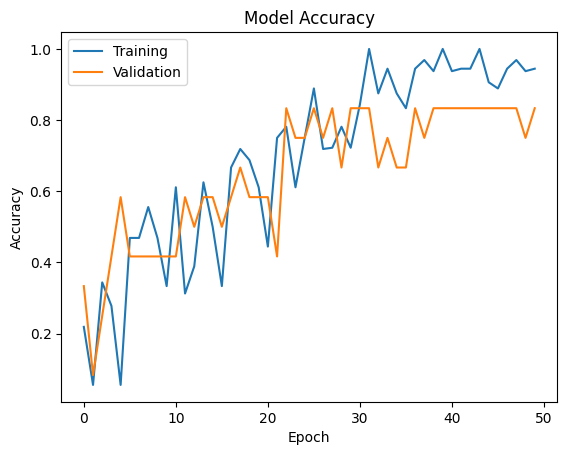

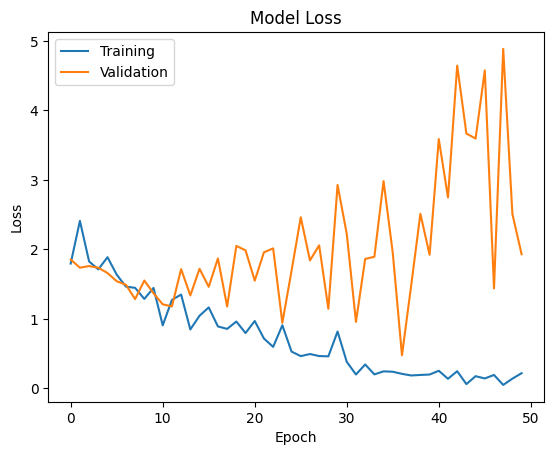

In [15]:
from tensorflow import keras
from tensorflow.keras.layers import Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# Path to data folders
data_dir = "/content/military_ribbon_dataset"

# Model parameters
img_width, img_height = 224, 224
batch_size = 32
epochs = 50  # Increase the number of epochs for better prediction quality

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2  # 20% of data for validation
)

# Pre-defining the list of classes
valid_classes = [d for d in os.listdir(data_dir) if not d.startswith('.')]
print(f"Valid classes: {valid_classes}")

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    classes = valid_classes # Use the pre-defined list of classes
)

validation_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    classes = valid_classes  # Use the pre-defined list of classes
)

# CNN Model
model = keras.Sequential([
    Input(shape=(img_width, img_height, 3)),
    keras.layers.Conv2D(32, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(128, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5), # Additional Dropout layer for regularization
    keras.layers.Dense(train_generator.num_classes, activation='softmax')  # Number of output classes
])

# Model compilation
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Model training
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,
    verbose=0
)

# Save the model
model.save('InsigniaNet_model.keras')

# Display accuracy and loss plots
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')
plt.show()

# Prediction of a new ribbon

This snippet predicts a new image and displays the probability with which it belongs to a given class. The name and location of the new image are defined in `img_path`.

In [17]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Load the model
model = keras.models.load_model('InsigniaNet_model.keras')

# Image path
img_path = '/content/military_ribbon_dataset/test.png'

# Load and preprocess the image
# Change target_size to (224, 224) to match the size the model was trained on
img = image.load_img(img_path, target_size=(224, 224))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = x / 255.0  # Normalization

# Make a prediction
predictions = model.predict(x)

# Get class names
class_names = list(train_generator.class_indices.keys())

# Display results
predicted_class_index = np.argmax(predictions[0])
predicted_class = class_names[predicted_class_index]
confidence = predictions[0][predicted_class_index] * 100

print(f"Predicted class: {predicted_class}")
print(f"Confidence: {confidence:.2f}%")

# Create a list of (class_name, confidence) pairs
class_confidences = []
for i in range(len(class_names)):
  class_confidences.append((class_names[i], predictions[0][i] * 100))

# Sort the list in descending order by confidence
class_confidences.sort(key=lambda x: x[1], reverse=True)

print("\nTop 3 predicted classes:")
for class_name, conf in class_confidences[:3]:
  print(f"{class_name}: {conf:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 599ms/step
Predicted class: Siły Zbrojne w Służbie Ojczyzny - srebrna
Confidence: 99.51%

Top 3 predicted classes:
Siły Zbrojne w Służbie Ojczyzny - srebrna: 99.51%
Medal za długoletnią służbę - srebrna: 0.26%
Siły Zbrojne w Służbie Ojczyzny - złota: 0.13%
